# ZTF × Gaia Halo Eclipsing Binary Workflow

## Overview

This notebook presents a reproducible workflow for identifying halo
eclipsing binary candidates from a sample of ZTF eclipsing binaries.

The workflow uses astrometric and radial-velocity information to calculate
Galactocentric positions and velocities, estimate orbital energy and the
z-component of angular momentum, and visualize the resulting stellar
population in an energy–angular momentum diagram.

## Workflow

The analysis follows these main steps:

1. Load the ZTF eclipsing binary catalogue.
2. Extract sky coordinates, proper motions, parallaxes, and radial velocities.
3. Estimate stellar distances from parallaxes.
4. Convert the positions to a simplified Galactocentric coordinate system.
5. Estimate stellar velocities and correct them for the Solar motion and Local Standard of Rest.
6. Calculate the total energy and the z-component of angular momentum.
7. Define a simple halo-candidate selection criterion using
   $\frac{J_\phi}{J_{\mathrm{tot}}} \leq 0.6$.
8. Visualize the selected halo candidates in an $E-L_z$ diagram.

## Requirements

The workflow requires Python and the following Python packages:

- NumPy
- pandas
- Matplotlib

The exact versions used for this workflow are specified in
`environment.yml`.

The input catalogue is provided separately as `ZTFEB.csv`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
csv_path = "data/ZTFEB.csv"
df = pd.read_csv(csv_path)

### Solar and Galactic parameters

The following Solar position and velocity parameters are adopted in the
calculation. The values are kept consistent with the original analysis.

In [4]:
X_sun = 8.3      # kpc
Z_sun = 0.02     # kpc
U_sun = 11.1     # km/s
V_sun = 12.24    # km/s
W_sun = 7.25     # km/s
V_LSR = 232.0    # km/s

### Coordinate and velocity calculation

The sky coordinates are converted from degrees to radians. Distances are
estimated from the measured parallax.

The resulting Cartesian coordinates are then shifted to a simplified
Galactocentric reference frame using the adopted Solar position.

Proper motions and radial velocities are used to estimate the three
components of stellar velocity. The Solar motion and the Local Standard
of Rest are subsequently subtracted.

In [7]:
ra = np.radians(df["ra"])            
dec = np.radians(df["dec"])
pmra = df["pmra"]
pmdec = df["pmdec"]
parallax = df["parallax"]
rv = df["radial_velocity"]

distance_pc = 1000.0 / parallax     
distance_kpc = distance_pc / 1000.0

x = distance_kpc * np.cos(dec) * np.cos(ra)
y = distance_kpc * np.cos(dec) * np.sin(ra)
z = distance_kpc * np.sin(dec)

xg = x - X_sun
yg = y
zg = z - Z_sun

vx = -pmra / 1000.0 * 4.74 * distance_kpc
vy = -pmdec / 1000.0 * 4.74 * distance_kpc
vz = rv

vx -= -U_sun
vy -= (V_LSR + V_sun)
vz -= W_sun

### Orbital energy and angular momentum

The total energy is estimated as

$$
E = \frac{1}{2}v^2 + \Phi(r),
$$

where the gravitational potential is approximated by

$$
\Phi(r) = -\frac{1}{r}.
$$

The z-component of angular momentum is calculated as

$$
L_z = x v_y - y v_x.
$$

These quantities are then used to construct an energy–angular momentum
diagram.

In [8]:
v2 = vx**2 + vy**2 + vz**2
r = np.sqrt(xg**2 + yg**2 + zg**2)
phi = -1.0 / r
E = 0.5 * v2 + phi

Lz = xg * vy - yg * vx

### Halo candidate selection

A simple angular-momentum-based criterion is used to identify halo
candidates.

Stars satisfying

$$
\frac{J_\phi}{J_{\mathrm{tot}}} \leq 0.6
$$

are classified as halo candidates for the purpose of this workflow.

This is a simplified selection criterion and should not be interpreted as
a complete dynamical classification of the Galactic halo.

In [9]:
Jphi = np.abs(Lz)
Jtot = np.abs(Lz) + np.abs(vx) + np.abs(vy) + np.abs(vz)
Jratio = Jphi / Jtot

halo_mask = Jratio <= 0.6

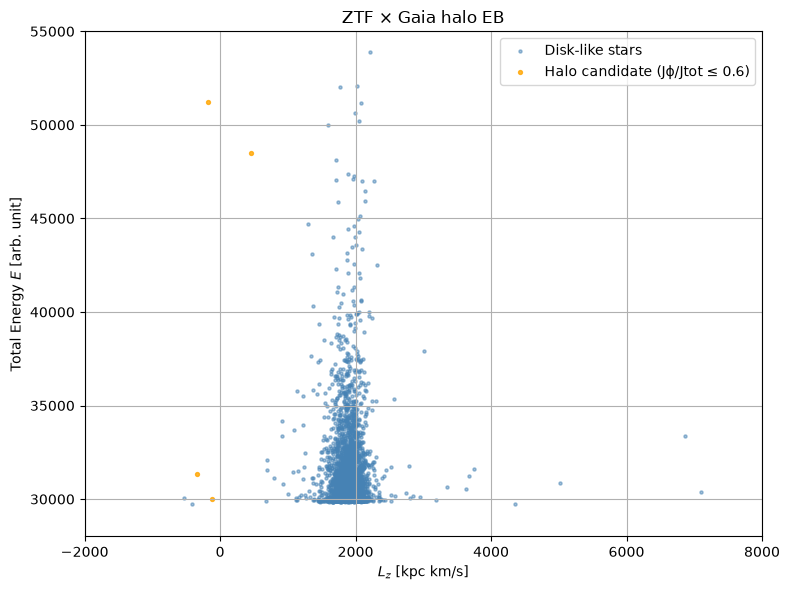

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(
    Lz[~halo_mask],
    E[~halo_mask],
    s=5,
    alpha=0.5,
    c='steelblue',
    label='Disk-like stars'
)

plt.scatter(
    Lz[halo_mask],
    E[halo_mask],
    s=8,
    alpha=0.8,
    c='orange',
    label='Halo candidate (Jϕ/Jtot ≤ 0.6)'
)

plt.xlabel("$L_z$ [kpc km/s]")
plt.ylabel("Total Energy $E$ [arb. unit]")
plt.title("ZTF × Gaia halo EB")
plt.xlim(-2000, 8000)
plt.ylim(28000, 55000)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

## Results

The energy–angular momentum diagram shows the distribution of the
ZTF eclipsing binary candidates in phase space.

Halo candidates are selected using the criterion

$\frac{J_\phi}{J_{\mathrm{tot}}} \leq 0.6$.

These candidates are highlighted separately from the disk-like population
in the $E-L_z$ diagram.

## Limitations

This workflow is a simplified implementation of the original analysis.

Several physical approximations are made. In particular, the gravitational
potential is represented by a simple \(-1/r\) form rather than a detailed
Milky Way potential. The velocity transformation is also implemented
explicitly rather than using a dedicated Galactic-coordinate package.

The halo selection criterion is therefore intended as a reproducible
demonstration of the original workflow rather than a complete dynamical
classification.

The results should be interpreted within the assumptions of the model.

# FAIR Data Principles

FAIR stands for Findable, Accessible, Interoperable, and Reusable.

## Findable

The workflow is stored in a GitHub repository with a descriptive project
name, a README file, metadata, and relevant keywords. The notebook and
input data are clearly identified.

## Accessible

The workflow code is openly available through the repository and can be
executed using the documented computational environment.

If the underlying astronomical data cannot be redistributed, the workflow
provides information about the required input data and its source.

## Interoperable

The workflow uses standard machine-readable CSV data and common Python
scientific-computing libraries such as NumPy, pandas, and Matplotlib.

The required input columns and processing steps are explicitly documented,
making the workflow easier to adapt to compatible datasets.

## Reusable

The workflow includes documentation, executable code, output figures,
dependency information, and an environment specification.

Version-pinned dependencies help reduce the risk that future software
changes will prevent the workflow from running or alter its results.